<a href="https://colab.research.google.com/github/dkumui/IPSD-Assignment/blob/main/MODUL%202%20-%20Pengolahan%20Data/Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Imputasi missing value dengan mean, median, dan modus**

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, MinMaxScaler

In [3]:
data = pd.read_csv('diabetes.csv')

data.head(), data.info(), data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               691 non-null    float64
 1   Glucose                   653 non-null    float64
 2   BloodPressure             614 non-null    float64
 3   SkinThickness             730 non-null    float64
 4   Insulin                   576 non-null    float64
 5   BMI                       538 non-null    float64
 6   DiabetesPedigreeFunction  691 non-null    float64
 7   Age                       614 non-null    float64
 8   Outcome                   768 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 54.1 KB


(   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
 0          6.0      NaN           72.0           35.0      0.0   NaN   
 1          1.0     85.0           66.0           29.0      0.0   NaN   
 2          8.0    183.0           64.0            0.0      0.0  23.3   
 3          1.0     89.0           66.0           23.0     94.0  28.1   
 4          0.0      NaN           40.0           35.0    168.0  43.1   
 
    DiabetesPedigreeFunction   Age  Outcome  
 0                     0.627   NaN        1  
 1                     0.351  31.0        0  
 2                     0.672  32.0        1  
 3                     0.167  21.0        0  
 4                       NaN  33.0        1  ,
 None,
        Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
 count   691.000000  653.000000     614.000000     730.000000  576.000000   
 mean      3.803184  120.462481      68.959283      20.520548   76.878472   
 std       3.333891   31.941336      19.76889

In [9]:
data_imputed = data.copy()

mean_impute_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in mean_impute_cols:
    data_imputed[col] = data_imputed[col].fillna(data_imputed[col].mean())

median_impute_cols = ['Age', 'Pregnancies']
for col in median_impute_cols:
    data_imputed[col] = data_imputed[col].fillna(data_imputed[col].median())

mode_impute_cols = ['Outcome']
for col in mode_impute_cols:
    data_imputed[col] = data_imputed[col].fillna(data_imputed[col].mode()[0])

data_imputed.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,77
Age,0
Outcome,0


Kodingan di atas digunakan untuk menangani missing values dalam dataset dengan metode imputasi yang sesuai, yaitu mean, median, dan mode, tergantung pada karakteristik kolomnya.

# **2. Cek korelasi antar variabel dengan heatmap**

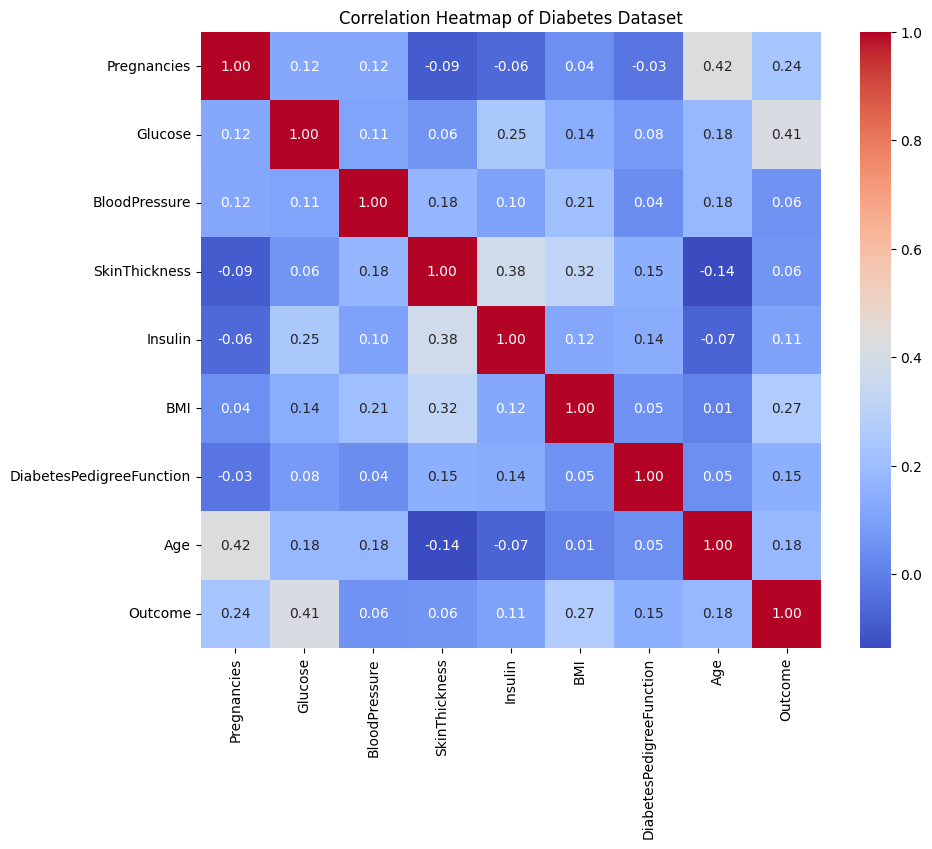

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [10]:
data_imputed['DiabetesPedigreeFunction'] = data_imputed['DiabetesPedigreeFunction'].fillna(data_imputed['DiabetesPedigreeFunction'].mean())

missing_values_check = data_imputed.isnull().sum()

plt.figure(figsize=(10, 8))
correlation_matrix = data_imputed.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap of Diabetes Dataset')
plt.show()

missing_values_check

Kodingan di atas digunakan untuk menangani missing values pada kolom 'DiabetesPedigreeFunction' dengan menggunakan metode imputasi mean dan untuk menganalisis hubungan antar-variabel dalam dataset menggunakan visualisasi heatmap.

# **3. Lakukan imbalance handling dengan undersampling**

In [6]:
outcome_distribution = data_imputed['Outcome'].value_counts()

majority_class = data_imputed[data_imputed['Outcome'] == 0]
minority_class = data_imputed[data_imputed['Outcome'] == 1]

undersampled_majority_class = majority_class.sample(len(minority_class), random_state=42)

balanced_data = pd.concat([undersampled_majority_class, minority_class])

new_outcome_distribution = balanced_data['Outcome'].value_counts()

outcome_distribution, new_outcome_distribution

(Outcome
 0    500
 1    268
 Name: count, dtype: int64,
 Outcome
 0    268
 1    268
 Name: count, dtype: int64)

Kodingan ini digunakan untuk menangani imbalance dalam distribusi variabel target 'Outcome' dengan menggunakan metode undersampling.

# **4. Lakukan scaling dengan robust scaler dan minmax**

In [8]:
robust_scaled_data = balanced_data.copy()
minmax_scaled_data = balanced_data.copy()

scale_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

robust_scaler = RobustScaler()
robust_scaled_data[scale_columns] = robust_scaler.fit_transform(robust_scaled_data[scale_columns])

minmax_scaler = MinMaxScaler()
minmax_scaled_data[scale_columns] = minmax_scaler.fit_transform(minmax_scaled_data[scale_columns])

robust_scaled_data.head(), minmax_scaled_data.head()

(     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
 556         -0.4 -0.710984       0.086726        0.56250  0.000000  0.000000   
 117          0.4  0.000000      -1.746607       -0.68750 -0.807123  0.416176   
 572          0.0 -0.286742      -0.913274        0.28125 -0.345181 -0.608215   
 251         -0.2  0.258713       1.253393       -0.68750 -0.807123 -0.974068   
 161          0.8 -0.559469       0.420060        0.56250  0.000000  1.269834   
 
      DiabetesPedigreeFunction       Age  Outcome  
 556                 -0.590302  0.083333        0  
 117                  0.635278 -0.333333        0  
 572                  0.005622 -0.583333        0  
 251                 -0.404779 -0.166667        0  
 161                 -0.629656  0.000000        0  ,
      Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
 556     0.058824  0.487437       0.614035       0.404040  0.141581  0.476806   
 117     0.294118  0.605339       0.4

Kodingan di atas digunakan untuk melakukan scaling pada fitur-fitur numerik dalam dataset menggunakan dua teknik berbeda: RobustScaler dan MinMaxScaler.